<a href="https://colab.research.google.com/github/kellllyyy/mase/blob/lab_kellyngmanyie/tutorial_3_qat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial 3: Running Quantization-Aware Training (QAT) on Bert

In this tutorial, we'll build on top of Tutorial 2 by taking the Bert model fine tuned for sequence classification and running Mase's quantization pass. First, we'll run simple Post-Training Quantization (PTQ) and see how much accuracy drops. Then, we'll run some further training iterations of the quantized model (i.e. QAT) and see whether the accuracy of the trained quantized model approaches the accuracy of the original (full-precision) model.

In [ ]:
%pip uninstall -y optimum transformers datasets evaluate fsspec
%pip install optimum==1.24.0 transformers==4.51 datasets==3.3.2 evaluate==0.4.3 fsspec==2024.12.0


Found existing installation: transformers 4.57.6
Uninstalling transformers-4.57.6:
  Successfully uninstalled transformers-4.57.6
Found existing installation: datasets 4.0.0
Uninstalling datasets-4.0.0:
  Successfully uninstalled datasets-4.0.0
Found existing installation: fsspec 2025.3.0
Uninstalling fsspec-2025.3.0:
  Successfully uninstalled fsspec-2025.3.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 433.6/433.6 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 101.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 84.3 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokeni

In [ ]:
%pip install \
black toml GitPython colorlog \
cocotb==1.9.2 pybind11 \
timm pytorch-nlp sentencepiece einops kornia \
hyperopt@git+https://github.com/hyperopt/hyperopt.git \
optuna stable-baselines3[extra] \
tensorboard tensorboardx wandb lightning pytorch-lightning \
bitarray "bitstring>=4.2" attr-dot-dict emoji \
onnx onnxruntime onnxconverter-common accelerate \
absl-py prettytable pynvml py-cpuinfo psutil cvxpy pydot \
h5py imageio imageio-ffmpeg \
opencv-python matplotlib scikit-learn pandas \
sphinx-rtd-theme "sphinx-needs>=4" \
sphinx-test-reports@git+https://github.com/useblocks/sphinx-test-reports \
sphinxcontrib-plantuml sphinx-glpi-theme \
ghp-import myst_parser myst-nb sphinx-book-theme \
ultralytics==8.3.235


  Cloning https://github.com/hyperopt/hyperopt.git to /tmp/pip-install-vtsbhoso/hyperopt_c226c2db956142b3a34f42c877101fca
  Running command git clone --filter=blob:none --quiet https://github.com/hyperopt/hyperopt.git /tmp/pip-install-vtsbhoso/hyperopt_c226c2db956142b3a34f42c877101fca
  Resolved https://github.com/hyperopt/hyperopt.git to commit 0658f680c84a313eaffe1771a20dfe2ebabd7fd4
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/useblocks/sphinx-test-reports to /tmp/pip-install-vtsbhoso/sphinx-test-reports_7f5a03a0aada4d2fb8c374d3a2f267e2
  Running command git clone --filter=blob:none --quiet https://github.com/useblocks/sphinx-test-reports /tmp/pip-install-vtsbhoso/sphinx-test-reports_7f5a03a0aada4d2fb8c374d3a2f267e2
  Resolved https://github.com/useblocks/sphinx-test-reports to commit 97df9daec4a50800ecb5cfdcd5a49416840750bf
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import os
os.kill(os.getpid(), 9)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/mase/src')
print(f"Added '/content/drive/MyDrive/mase/src' to sys.path")

Added '/content/drive/MyDrive/mase/src' to sys.path


In [ ]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

## Importing the model

If you are starting from scratch, you can create a MaseGraph for Bert by running the following cell.

In [ ]:
from transformers import AutoModelForSequenceClassification

from chop import MaseGraph
import chop.passes as passes

model = AutoModelForSequenceClassification.from_pretrained(checkpoint)
model.config.problem_type = "single_label_classification"

mg = MaseGraph(
    model,
    hf_input_names=[
        "input_ids",
        "attention_mask",
        "labels",
    ],
)

mg, _ = passes.init_metadata_analysis_pass(mg)
mg, _ = passes.add_common_metadata_analysis_pass(mg)

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of you

config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
`past_key_values` were not specified as input names, but model.config.use_cache = True. Setting model.config.use_cache = False.
W0202 14:36:59.251000 668 torch/fx/_symbolic_trace.py:52] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.
INFO     Getting dummy input for prajjwal1/bert-tiny.


vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]],


        [[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       

If you have previously ran the tutorial on LoRA Finetuning, run the following cell to import the fine tuned checkpoint.

In [ ]:
from pathlib import Path
from chop import MaseGraph

# mg = MaseGraph.from_checkpoint(f"{Path.home()}/tutorial_2_lora")

mg = MaseGraph.from_checkpoint("/content/drive/MyDrive/mase/src/tutorial_2_lora")

WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.


## Post-Training Quantization (PTQ)

Here, we simply quantize the model and evaluate the effect in its accuracy. First, let's evaluate the model accuracy before quantization (if you're coming from Tutorial 2, this should be the same as the post-LoRA evaluation accuracy). As seen in Tutorial 2, we can use the `get_tokenized_dataset` and `get_trainer` utilities to generate a HuggingFace `Trainer` instance for training and evaluation.

In [ ]:
from chop.tools import get_tokenized_dataset, get_trainer

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
)

# Evaluate accuracy
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

...

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

/content/drive/MyDrive/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Evaluation accuracy: 0.83496


To run the quantization pass, we pass a quantization configuration dictionary as argument. This defines the quantization mode, numerical format and precision for each operator in the graph. We'll run the quantization in "by type" mode, meaning nodes are quantized according to their `mase_op`. Other modes include by name and by regex name. We'll quantize all activations, weights and biases in the model to fixed-point with the same precision. This may be sub-optimal, but works as an example. In future tutorials, we'll see how to run the `search` flow in `Mase` to find optimal quantization configurations to minimize accuracy loss.

In [ ]:
import chop.passes as passes

quantization_config = {
    "by": "type",
    "default": {
        "config": {
            "name": None,
        }
    },
    "linear": {
        "config": {
            "name": "integer",
            # data
            "data_in_width": 8,
            "data_in_frac_width": 4,
            # weight
            "weight_width": 8,
            "weight_frac_width": 4,
            # bias
            "bias_width": 8,
            "bias_frac_width": 4,
        }
    },
}

mg, _ = passes.quantize_transform_pass(
    mg,
    pass_args=quantization_config,
)

Let's evaluate the immediate effect of quantization on the model accuracy.

In [ ]:
trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
)
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

/content/drive/MyDrive/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Evaluation accuracy: 0.79388


We can save the current checkpoint for future reference (optional).

In [ ]:
from pathlib import Path

# mg.export(f"{Path.home()}/tutorial_3_ptq")
mg.export("/content/drive/MyDrive/mase/src/tutorial_3_ptq")



INFO     Exporting MaseGraph to /content/drive/MyDrive/mase/src/tutorial_3_ptq.pt, /content/drive/MyDrive/mase/src/tutorial_3_ptq.mz
INFO     Exporting GraphModule to /content/drive/MyDrive/mase/src/tutorial_3_ptq.pt
INFO     Saving full model format
INFO     Exporting MaseMetadata to /content/drive/MyDrive/mase/src/tutorial_3_ptq.mz


## Quantization-Aware Training (QAT)

You should have seen in the last section that quantization can lead to a significant drop in accuracy. Next, we'll run QAT to evaluate whether this performance gap can be reduced. To run QAT in Mase, all you need to do is include the model back in your training loop after running the quantization pass.

In [ ]:
# Evaluate accuracy
trainer.train()
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

Step,Training Loss
500,0.399700
1000,0.396000
1500,0.401900
2000,0.379600
2500,0.390600
3000,0.385700


Evaluation accuracy: 0.84048


We can see the accuracy of the quantized model can match (or sometimes exceed) the full precision model, with a much lower memory requirement to store the weights. Finally, save the final checkpoint for future tutorials.

In [ ]:
from pathlib import Path

# mg.export(f"{Path.home()}/tutorial_3_qat")
mg.export("/content/drive/MyDrive/mase/src/tutorial_3_qat")

INFO     Exporting MaseGraph to /content/drive/MyDrive/mase/src/tutorial_3_qat.pt, /content/drive/MyDrive/mase/src/tutorial_3_qat.mz
INFO     Exporting GraphModule to /content/drive/MyDrive/mase/src/tutorial_3_qat.pt
INFO     Saving full model format
INFO     Exporting MaseMetadata to /content/drive/MyDrive/mase/src/tutorial_3_qat.mz


## Implementation tasks

In Tutorial 3, you quantized every Linear layer in the model to the provided configuration. Now, explore a range of fixed point widths from 4 to 32.

Plot a figure where the x-axis is the fixed point width and the y-axis is the highest achieved accuracy on the IMDb dataset, following the procedure in Tutorial 3.

Plot separate curves for PTQ and QAT at each precision to show the effect of post-quantization finetuning.

Take your best obtained model from Task 1 and rerun the pruning procedure, this time varying the sparsity from 0.1 to 0.9.

Plot a figure where the x-axis is the sparsity and the y-axis is the highest achieved accuracy on the IMDb dataset, following the procedure in Tutorial 4.

Plot separate curves for Random and L1-Norm methods to evaluate the effect of different pruning strategies.



Testing fixed point width: 4


WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.
/content/drive/MyDrive/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


PTQ Accuracy (width=4): 0.5000


Step,Training Loss
500,0.693100
1000,0.693100
1500,0.693100
2000,0.693100
2500,0.693100
3000,0.693100


WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.


...

QAT Accuracy (width=28): 0.8418

Testing fixed point width: 32


/content/drive/MyDrive/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


PTQ Accuracy (width=32): 0.8349


Step,Training Loss
500,0.387900
1000,0.383000
1500,0.394100
2000,0.367100
2500,0.381700
3000,0.379800


QAT Accuracy (width=32): 0.8418


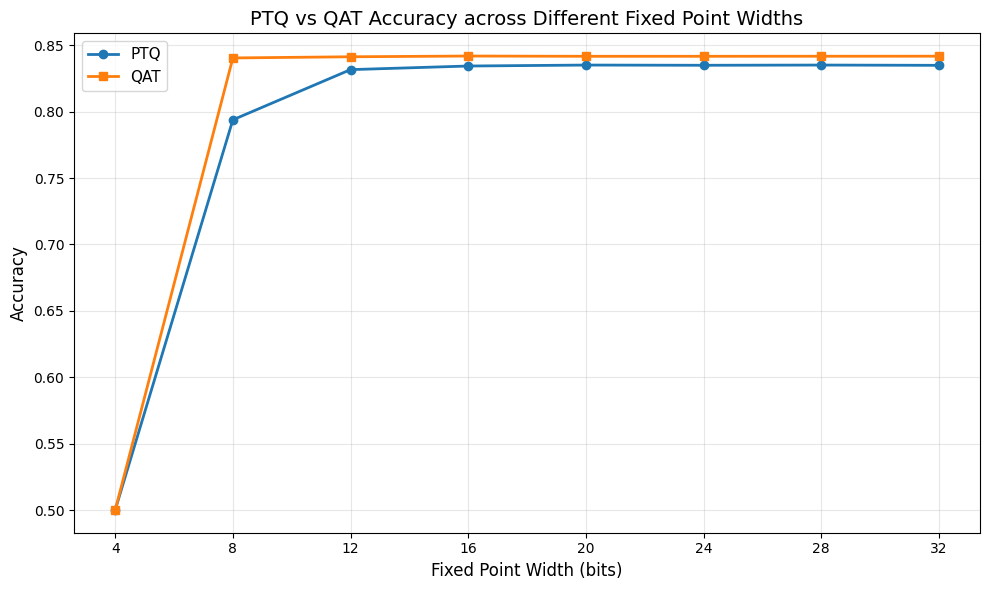


Summary of Results:
Width      PTQ Accuracy    QAT Accuracy    QAT Gain       
------------------------------------------------------------
4          0.5000          0.5000          0.0000         
8          0.7939          0.8405          0.0466         
12         0.8317          0.8414          0.0097         
16         0.8344          0.8419          0.0075         
20         0.8351          0.8417          0.0066         
24         0.8350          0.8417          0.0068         
28         0.8351          0.8418          0.0066         
32         0.8349          0.8418          0.0069         


In [ ]:
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

# Define the range of fixed point widths to explore
widths = [4, 8, 12, 16, 20, 24, 28, 32]

# Store results
ptq_accuracies = []
qat_accuracies = []

for width in widths:
    print(f"\n{'='*60}")
    print(f"Testing fixed point width: {width}")
    print(f"{'='*60}")

    # Reload the model from checkpoint (before quantization)
    # mg_fresh = MaseGraph.from_checkpoint(f"{Path.home()}/tutorial_2_lora")
    mg_fresh = MaseGraph.from_checkpoint("/content/drive/MyDrive/mase/src/tutorial_2_lora")

    # Define quantization config for current width
    quantization_config_test = {
        "by": "type",
        "default": {
            "config": {
                "name": None,
            }
        },
        "linear": {
            "config": {
                "name": "integer",
                # data
                "data_in_width": width,
                "data_in_frac_width": width // 2,
                # weight
                "weight_width": width,
                "weight_frac_width": width // 2,
                # bias
                "bias_width": width,
                "bias_frac_width": width // 2,
            }
        },
    }

    # Apply quantization
    mg_fresh, _ = passes.quantize_transform_pass(
        mg_fresh,
        pass_args=quantization_config_test,
    )

    # Evaluate PTQ accuracy
    trainer_ptq = get_trainer(
        model=mg_fresh.model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
    )
    eval_results_ptq = trainer_ptq.evaluate()
    ptq_accuracy = eval_results_ptq['eval_accuracy']
    ptq_accuracies.append(ptq_accuracy)
    print(f"PTQ Accuracy (width={width}): {ptq_accuracy:.4f}")

    # Run QAT
    trainer_ptq.train()
    eval_results_qat = trainer_ptq.evaluate()
    qat_accuracy = eval_results_qat['eval_accuracy']
    qat_accuracies.append(qat_accuracy)
    print(f"QAT Accuracy (width={width}): {qat_accuracy:.4f}")

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(widths, ptq_accuracies, marker='o', label='PTQ', linewidth=2)
plt.plot(widths, qat_accuracies, marker='s', label='QAT', linewidth=2)
plt.xlabel('Fixed Point Width (bits)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('PTQ vs QAT Accuracy across Different Fixed Point Widths', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(widths)
plt.tight_layout()
# plt.savefig(f"{Path.home()}/ptq_vs_qat_accuracy.png", dpi=300, bbox_inches='tight')
plt.savefig(f"/content/drive/MyDrive/mase/src/ptq_vs_qat_accuracy.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("Summary of Results:")
print("="*60)
print(f"{'Width':<10} {'PTQ Accuracy':<15} {'QAT Accuracy':<15} {'QAT Gain':<15}")
print("-"*60)
for i, width in enumerate(widths):
    gain = qat_accuracies[i] - ptq_accuracies[i]
    print(f"{width:<10} {ptq_accuracies[i]:<15.4f} {qat_accuracies[i]:<15.4f} {gain:<15.4f}")

To save a copy to github go to -> https://colab.research.google.com/github/ to enable inlude private repo